In [1]:
import os
import numpy as np
import spikeinterface.extractors as se
from matplotlib import pyplot as plt
from spikeinterface.preprocessing import bandpass_filter, common_reference, correct_motion, load_motion_info
from spikeinterface.widgets import plot_motion
import spikeinterface.full as si

/root/miniconda3/envs/spk_res/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing with kilosort_like


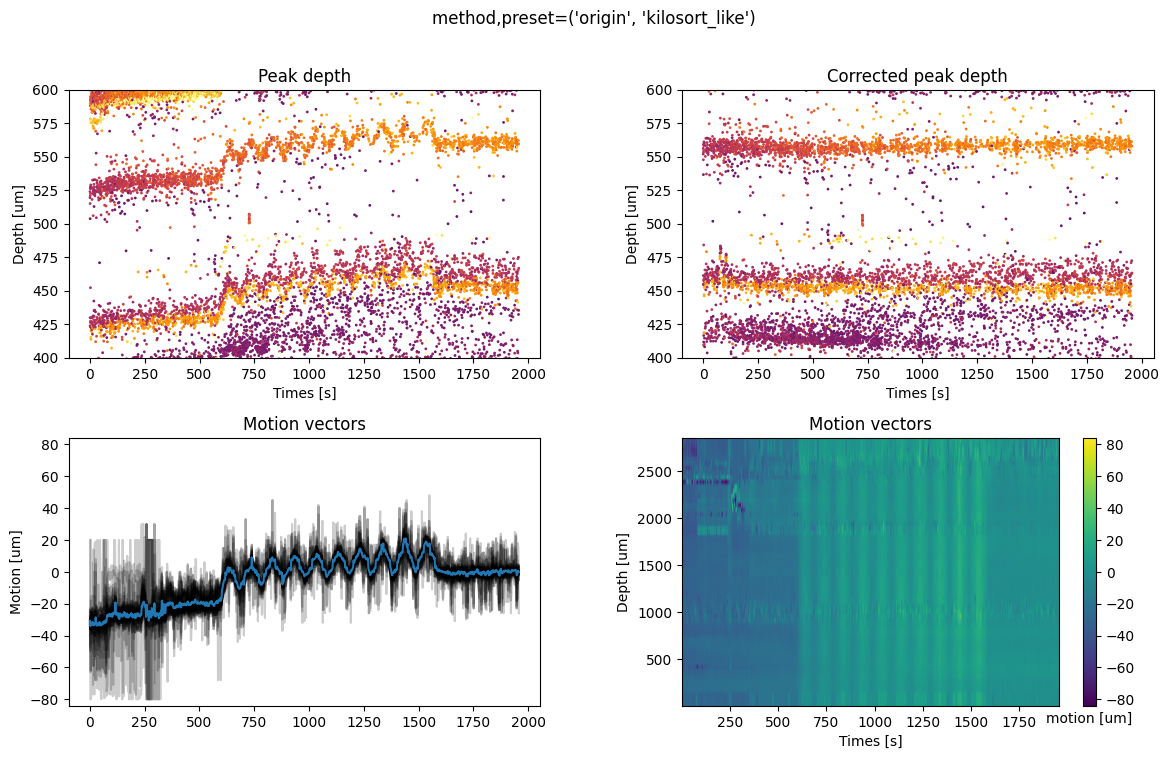

Computing with kilosort_like


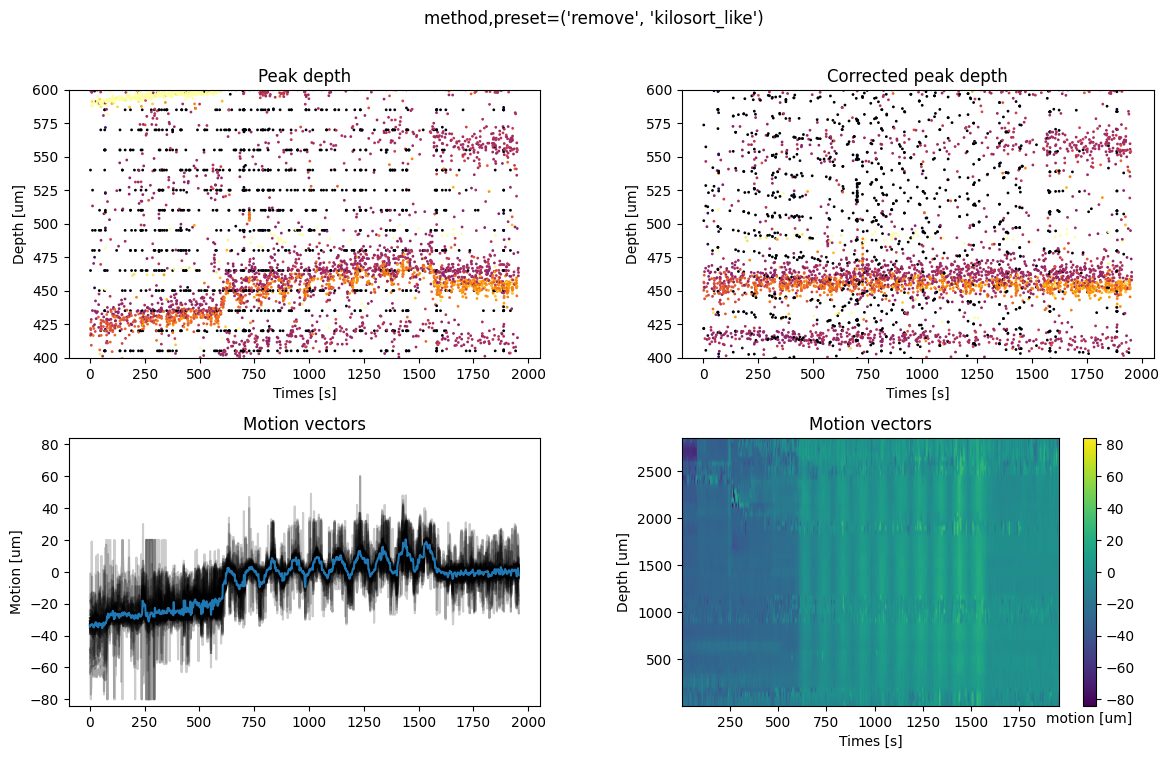

Computing with kilosort_like


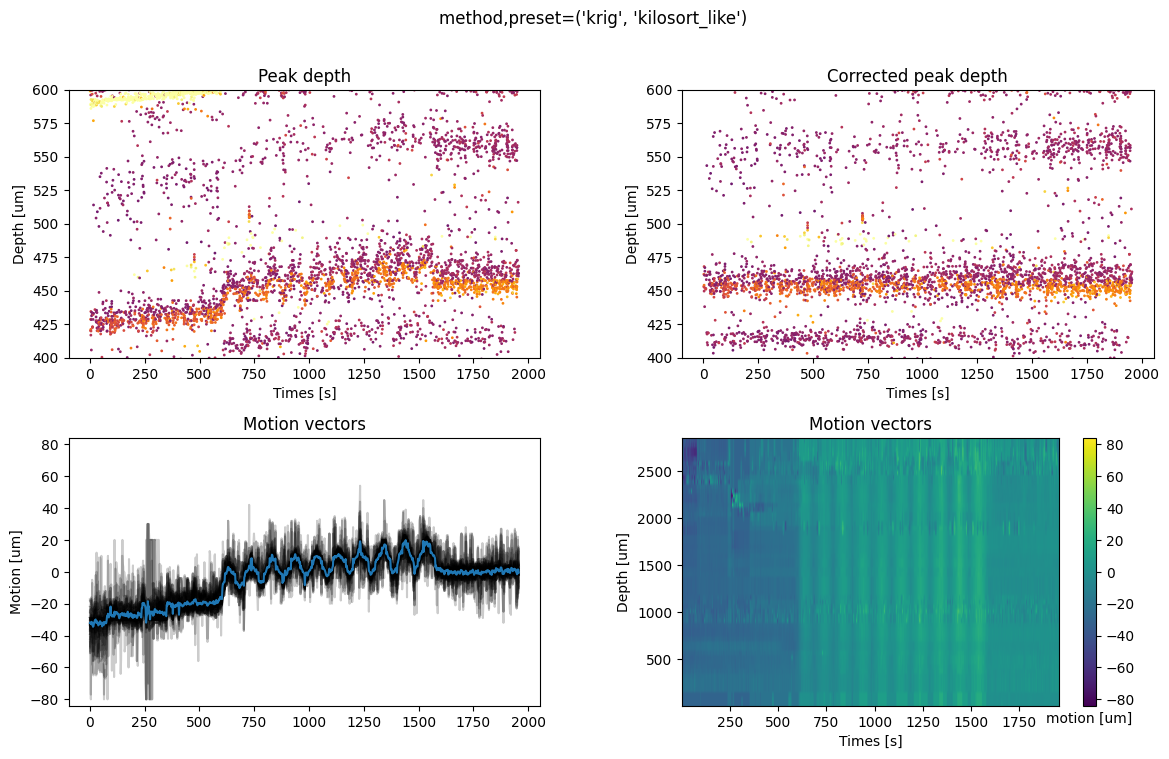

Computing with kilosort_like


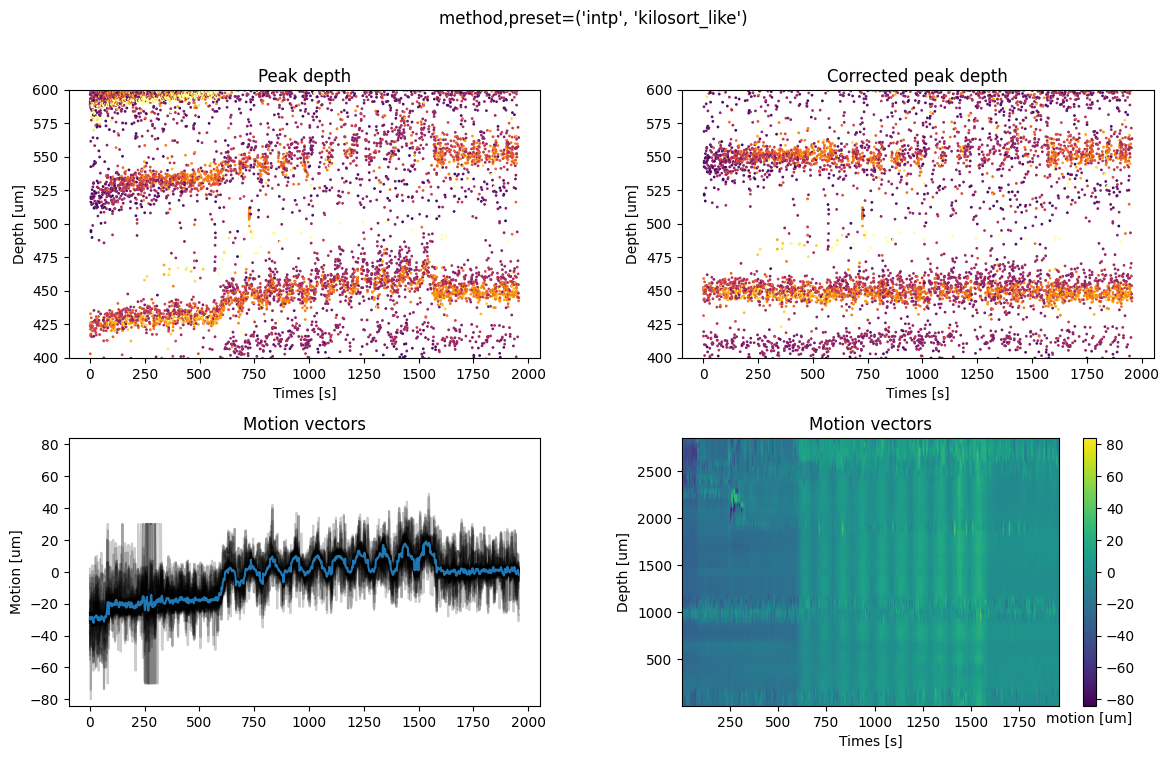

Computing with kilosort_like


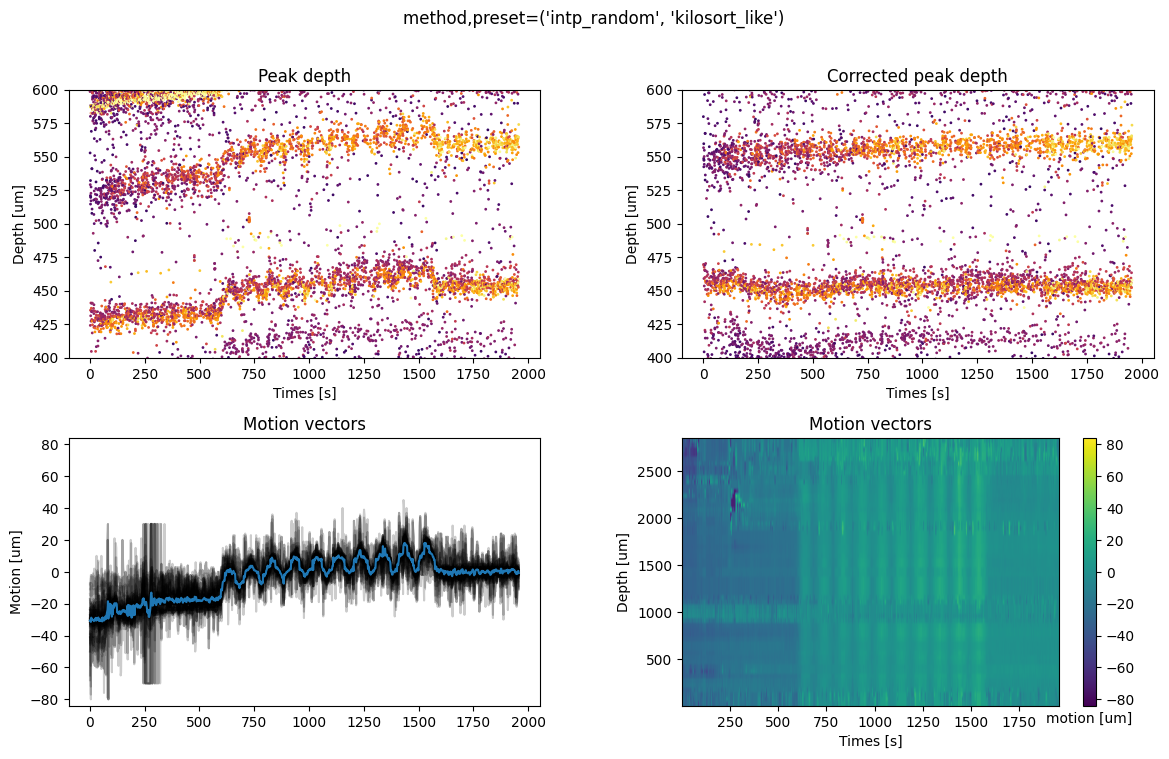

In [2]:
factor = 2
slt_probe = 'p2'
spikeglx_base_folder = 'imposed_motion_datasets'
slt_dataset = 'dataset1'

# origin
dataset1_folder = os.path.join(spikeglx_base_folder,'{}/{}'.format(slt_dataset,slt_probe))
origin_rec = se.read_spikeglx(dataset1_folder)

# bad chans
# 确定坏通道
channel_num = len(origin_rec.channel_ids)
channel_ids = np.arange(len(origin_rec.channel_ids))
bad_chans = channel_ids[channel_ids % factor == 1]
good_chans = channel_ids[~np.isin(channel_ids, bad_chans)]

# remove
rmv_weights = np.zeros([len(good_chans), len(bad_chans)])
rmv_rec = si.interpolate_bad_channels(origin_rec, origin_rec.channel_ids[bad_chans], weights=rmv_weights)

# krig
krig_rec = si.interpolate_bad_channels(origin_rec, origin_rec.channel_ids[bad_chans])

# intp
dataset1_intp_folder = os.path.join(spikeglx_base_folder,'{}/{}_intp'.format(slt_dataset,slt_probe))
intp_rec = se.read_spikeglx(dataset1_intp_folder)

# intp
dataset1_intp_folder = os.path.join(spikeglx_base_folder,'{}/{}_intp'.format(slt_dataset,slt_probe))
intp_rec_random = se.read_spikeglx(dataset1_intp_folder)


method_list = {'origin':origin_rec,
               'remove':rmv_rec,
               'krig':krig_rec,
               'intp':intp_rec,
               'intp_random':intp_rec_random}

# method_list = {'intp':intp_rec}

for method in method_list.keys():
    # 预处理：运动估计前最好不要ZCA白化
    if method == 'origin':
        motion_folder = 'spike_drift/{}/{}'.format(slt_dataset,method)
    # elif method == 'intp_random':
    #     motion_folder = 'spike_drift_random/{}/drift_factor{}/{}'.format(slt_dataset,factor,method)
    else:
        motion_folder = 'spike_drift/{}/drift_factor{}/{}'.format(slt_dataset,factor,method)
        
    rec = method_list[method]

    # nonrigid_accurate：非刚性配准
    job_kwargs = dict(n_jobs=20, chunk_duration='2s', progress_bar=True)
    # job_kwargs = dict(n_jobs=40, chunk_duration='1s', progress_bar=True,
    #                   estimate_motion_kwargs={'pairwise_displacement_method':'phase_cross_correlation'})

    some_presets =['kilosort_like']

    for preset in some_presets:
        print('Computing with', preset)
        folder = os.path.join(motion_folder,preset)
        if not os.path.exists(folder):
            os.makedirs(folder)
            rec = bandpass_filter(recording=rec, freq_min=300., freq_max=6000.)  # 带通滤波
            rec = common_reference(recording=rec, reference='global', operator='median')  # 去共模
            recording_corrected, motion_info = correct_motion(rec, preset=preset, folder=folder,
                                                     output_motion_info=True, **job_kwargs)

    # 显示结果
    for preset in some_presets:
        # load
        folder = os.path.join(motion_folder,preset)
        motion_info = load_motion_info(folder)

        peaks = motion_info["peaks"]
        peak_locations = motion_info["peak_locations"]

        # and plot
        fig = plt.figure(figsize=(14, 8))
        plot_motion(motion_info, figure=fig, depth_lim=(400,600),
                       color_amplitude=True, amplitude_cmap='inferno', scatter_decimate=10)
        fig.suptitle(f"{method,preset=}")

    plt.show()
